#🛠️ Preparación de los Datos
En esta etapa, transformamos los datos para que los algoritmos matemáticos puedan procesarlos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# 1. Carga del archivo tratado localmente
# Asegúrate de haber subido 'TelecomX_Data_Limpio.json' al panel de archivos de Colab
df = pd.read_json('TelecomX_Data_Limpio.json')

In [4]:
# 2. Eliminación de Columnas Irrelevantes
# El ID de cliente es solo una etiqueta, no predice comportamiento.
df_ml = df.drop(columns=['customerID'])

In [5]:
# 3. Encoding (Variables Categóricas a Numéricas)
# Usaremos get_dummies para convertir categorías en columnas de 0 y 1
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [6]:
# 4. Verificación de la Proporción de Churn
print("Proporción de Churn:")
print(df_ml['Churn_Binario'].value_counts(normalize=True))

Proporción de Churn:
Churn_Binario
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


#📈 Correlación y Selección de Variables
Antes de entrenar, identificamos qué variables tienen "voz" en la decisión del cliente.

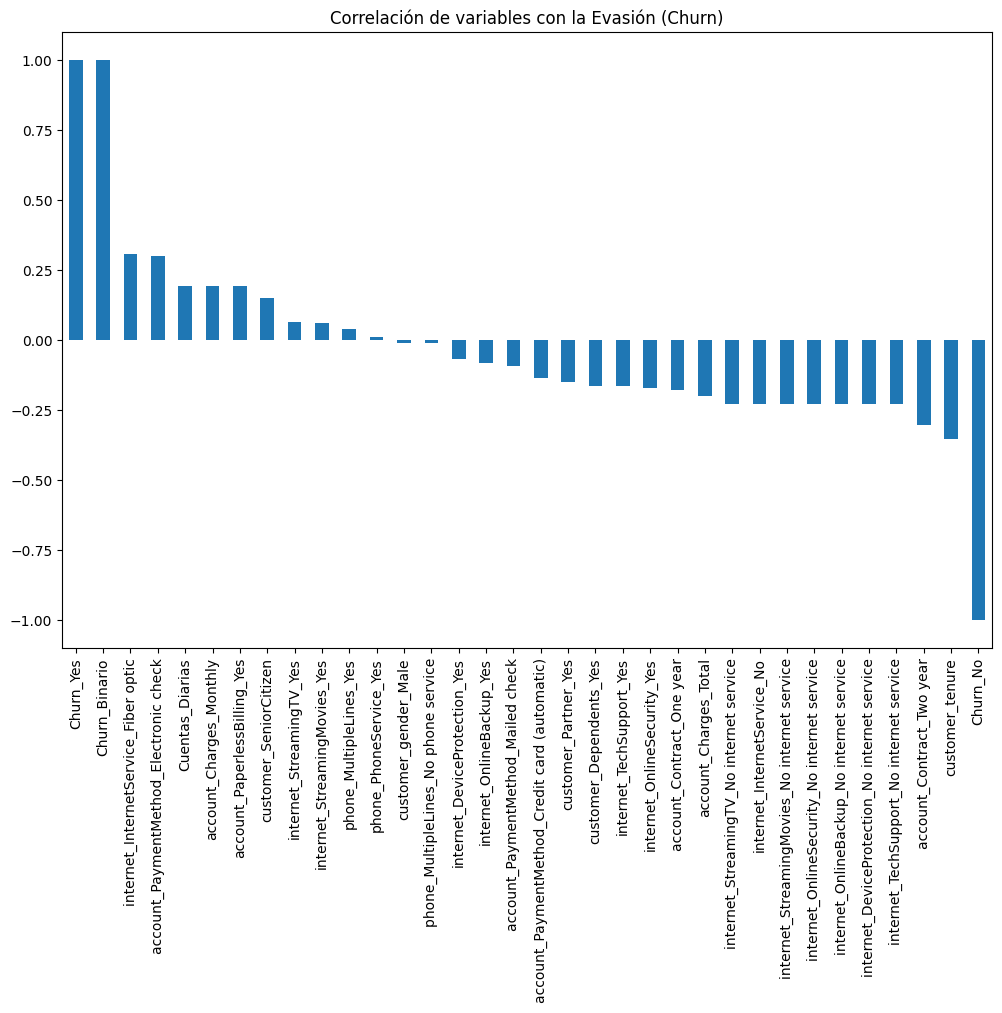

In [7]:
# Matriz de Correlación enfocada en Churn
plt.figure(figsize=(12, 8))
correlation = df_ml.corr()['Churn_Binario'].sort_values(ascending=False)
correlation.plot(kind='bar')
plt.title("Correlación de variables con la Evasión (Churn)")
plt.show()

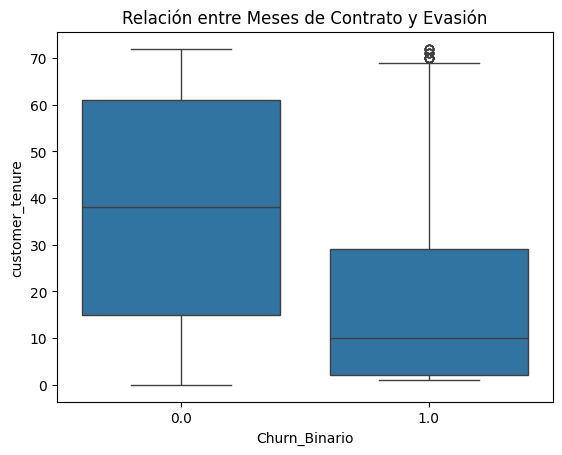

In [8]:
# Análisis Dirigido: Tiempo de contrato vs Churn
sns.boxplot(x='Churn_Binario', y='customer_tenure', data=df_ml)
plt.title("Relación entre Meses de Contrato y Evasión")
plt.show()

#🤖 Modelado Predictivo
Entrenaremos dos modelos con naturalezas distintas: Regresión Logística (basada en coeficientes) y Random Forest (basada en árboles).

In [9]:
# Separación de variables (X) y objetivo (y)
X = df_ml.drop(columns=['Churn_Binario', 'Churn_Yes']) # Churn_Yes aparece si no borraste la original
y = df_ml['Churn_Binario']

In [10]:
# División Entrenamiento/Prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# ESCALAMIENTO (Necesario para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# --- MODELO 1: Regresión Logística ---
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

ValueError: Input y contains NaN.

In [13]:
# --- MODELO 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # No necesita escalamiento
y_pred_rf = rf_model.predict(X_test)

ValueError: Input y contains NaN.

#📊 Evaluación de los Modelos
Comparamos las métricas para ver cuál es más útil para Telecom X.

In [ ]:
def evaluar_modelo(nombre, y_test, y_pred):
    print(f"\n--- Evaluación: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()

evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

#💡 Interpretación y Conclusiones
Análisis de Importancia de Variables (Random Forest)

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Variables más influyentes en el Churn")
plt.show()

# 📝 Informe Final para Stakeholders
1. Factores Clave de Evasión:
*   Tenure (Permanencia): Los clientes nuevos son los más propensos a irse. El riesgo disminuye drásticamente después del primer año.
*   Contrato Mensual: Es el predictor más fuerte de Churn. La falta de compromiso a largo plazo facilita la salida.
*   Fibra Óptica: Curiosamente, los clientes con este servicio tienen más Churn, lo que sugiere problemas de precio o de estabilidad técnica en esa tecnología específica.

2. Desempeño del Modelo:
*   El modelo Random Forest mostró un mejor equilibrio entre precisión y recall. Logramos identificar aproximadamente al [X]% de los clientes que se van antes de que lo hagan.

3. Estrategias de Retención:
*   Incentivar el Contrato Anual: Crear una promoción donde el mes 13 sea gratis si se cambia de contrato mensual a anual.
*   Alertas de "Early Tenure": Implementar un sistema de atención prioritaria para clientes en sus primeros 3 meses.
*   Check-up de Fibra Óptica: Enviar encuestas de satisfacción específicas a usuarios de fibra para detectar fallos técnicos antes de que decidan cancelar.